In [5]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, desc
import pandas as pd
import matplotlib.pyplot as plt

# Create Spark Session
spark = SparkSession.builder \
    .appName("StudentPerformanceAnalysis") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

# Set log level to reduce clutter
spark.sparkContext.setLogLevel("ERROR")

print("Spark Session Created Successfully!")
print(f"Spark Version: {spark.version}")

Spark Session Created Successfully!
Spark Version: 4.1.1


In [7]:
import csv
import os

print("Creating students.csv file...")

data = [
    ['ID', 'Name', 'Department', 'Marks'],
    [1, 'Alice', 'Computer Science', 85],
    [2, 'Bob', 'Mathematics', 72],
    [3, 'Charlie', 'Computer Science', 91],
    [4, 'Diana', 'Physics', 78],
    [5, 'Eve', 'Mathematics', 88],
    [6, 'Frank', 'Physics', 65],
    [7, 'Grace', 'Computer Science', 95],
    [8, 'Henry', 'Mathematics', 45],
    [9, 'Ivy', 'Physics', 82],
    [10, 'Jack', 'Computer Science', 76],
    [11, 'Kate', 'Mathematics', 93],
    [12, 'Leo', 'Physics', 59],
    [13, 'Mia', 'Computer Science', 88],
    [14, 'Noah', 'Mathematics', 71],
    [15, 'Olivia', 'Physics', 84],
    [16, 'Peter', 'Computer Science', 67],
    [17, 'Quinn', 'Mathematics', 79],
    [18, 'Rachel', 'Physics', 92],
    [19, 'Sam', 'Computer Science', 74],
    [20, 'Tina', 'Mathematics', 86],
    [21, 'Uma', 'Physics', ''],
    [22, 'Victor', 'Computer Science', ''],
    [23, 'Wendy', 'Mathematics', 73]
]

with open('students.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerows(data)

print("✅ students.csv created successfully!")
print(f"✅ File location: {os.getcwd()}\\students.csv")

Creating students.csv file...
✅ students.csv created successfully!
✅ File location: C:\Users\ZEESHAN\students.csv


In [8]:
# Load the CSV file
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("students.csv")

# Show the schema
print("Dataset Schema:")
df.printSchema()

# Show first few rows
print("\nFirst 5 rows of the dataset:")
df.show(5)

# Count total records
print(f"\nTotal number of records: {df.count()}")

Dataset Schema:
root
 |-- ID: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Department: string (nullable = true)
 |-- Marks: integer (nullable = true)


First 5 rows of the dataset:
+---+-------+----------------+-----+
| ID|   Name|      Department|Marks|
+---+-------+----------------+-----+
|  1|  Alice|Computer Science|   85|
|  2|    Bob|     Mathematics|   72|
|  3|Charlie|Computer Science|   91|
|  4|  Diana|         Physics|   78|
|  5|    Eve|     Mathematics|   88|
+---+-------+----------------+-----+
only showing top 5 rows

Total number of records: 23


In [16]:
# Import needed functions at the top
from pyspark.sql.functions import col, sum as spark_sum, isnan, when, count

# Check for missing values before cleaning
print("Records with missing values:")
df.filter(col("Marks").isNull() | isnan("Marks")).show()

# Clean missing values - drop rows with null marks
df_clean = df.dropna(subset=["Marks"])

print(f"\nRecords before cleaning: {df.count()}")
print(f"Records after cleaning: {df_clean.count()}")
print(f"Removed {df.count() - df_clean.count()} records with missing values")

# Show cleaned dataset
print("\nCleaned Dataset:")
df_clean.show()

# Check for null values - FIXED VERSION
print("\nNull values count per column:")
for column_name in df.columns:
    null_count = df.filter(col(column_name).isNull()).count()
    print(f"  {column_name}: {null_count} null values")

Records with missing values:
+---+------+----------------+-----+
| ID|  Name|      Department|Marks|
+---+------+----------------+-----+
| 21|   Uma|         Physics| NULL|
| 22|Victor|Computer Science| NULL|
+---+------+----------------+-----+


Records before cleaning: 23
Records after cleaning: 21
Removed 2 records with missing values

Cleaned Dataset:
+---+-------+----------------+-----+
| ID|   Name|      Department|Marks|
+---+-------+----------------+-----+
|  1|  Alice|Computer Science|   85|
|  2|    Bob|     Mathematics|   72|
|  3|Charlie|Computer Science|   91|
|  4|  Diana|         Physics|   78|
|  5|    Eve|     Mathematics|   88|
|  6|  Frank|         Physics|   65|
|  7|  Grace|Computer Science|   95|
|  8|  Henry|     Mathematics|   45|
|  9|    Ivy|         Physics|   82|
| 10|   Jack|Computer Science|   76|
| 11|   Kate|     Mathematics|   93|
| 12|    Leo|         Physics|   59|
| 13|    Mia|Computer Science|   88|
| 14|   Noah|     Mathematics|   71|
| 15| Olivia|

In [10]:
# Check for missing values before cleaning
print("Records with missing values:")
df.filter(col("Marks").isNull() | col("Name").isNull()).show()

# Clean missing values - drop rows with null marks
df_clean = df.dropna(subset=["Marks"])

# Alternative: Fill missing marks with 0 (if you prefer)
# df_clean = df.fillna({"Marks": 0})

print(f"\nRecords before cleaning: {df.count()}")
print(f"Records after cleaning: {df_clean.count()}")
print(f"Removed {df.count() - df_clean.count()} records with missing values")

# Show cleaned dataset
print("\nCleaned Dataset:")
df_clean.show()

Records with missing values:
+---+------+----------------+-----+
| ID|  Name|      Department|Marks|
+---+------+----------------+-----+
| 21|   Uma|         Physics| NULL|
| 22|Victor|Computer Science| NULL|
+---+------+----------------+-----+


Records before cleaning: 23
Records after cleaning: 21
Removed 2 records with missing values

Cleaned Dataset:
+---+-------+----------------+-----+
| ID|   Name|      Department|Marks|
+---+-------+----------------+-----+
|  1|  Alice|Computer Science|   85|
|  2|    Bob|     Mathematics|   72|
|  3|Charlie|Computer Science|   91|
|  4|  Diana|         Physics|   78|
|  5|    Eve|     Mathematics|   88|
|  6|  Frank|         Physics|   65|
|  7|  Grace|Computer Science|   95|
|  8|  Henry|     Mathematics|   45|
|  9|    Ivy|         Physics|   82|
| 10|   Jack|Computer Science|   76|
| 11|   Kate|     Mathematics|   93|
| 12|    Leo|         Physics|   59|
| 13|    Mia|Computer Science|   88|
| 14|   Noah|     Mathematics|   71|
| 15| Olivia|

In [11]:
# Group by Department and calculate average marks
avg_marks_per_dept = df_clean.groupBy("Department") \
    .agg(avg("Marks").alias("Average_Marks")) \
    .orderBy(desc("Average_Marks"))

print("Average Marks by Department:")
avg_marks_per_dept.show()

# Round the averages to 2 decimal places
from pyspark.sql.functions import round as spark_round

avg_marks_per_dept_rounded = df_clean.groupBy("Department") \
    .agg(spark_round(avg("Marks"), 2).alias("Average_Marks")) \
    .orderBy(desc("Average_Marks"))

print("Average Marks by Department (Rounded to 2 decimal places):")
avg_marks_per_dept_rounded.show()

Average Marks by Department:
+----------------+-----------------+
|      Department|    Average_Marks|
+----------------+-----------------+
|Computer Science|82.28571428571429|
|         Physics|76.66666666666667|
|     Mathematics|           75.875|
+----------------+-----------------+

Average Marks by Department (Rounded to 2 decimal places):
+----------------+-------------+
|      Department|Average_Marks|
+----------------+-------------+
|Computer Science|        82.29|
|         Physics|        76.67|
|     Mathematics|        75.88|
+----------------+-------------+



In [12]:
# Find top 5 students based on marks
top_5_students = df_clean.orderBy(desc("Marks")) \
    .select("ID", "Name", "Department", "Marks") \
    .limit(5)

print("Top 5 Students by Marks:")
top_5_students.show()

# Add rank to the students
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

window_spec = Window.orderBy(desc("Marks"))
students_with_rank = df_clean.withColumn("Rank", row_number().over(window_spec))

print("\nTop 5 Students with Rank:")
students_with_rank.select("Rank", "Name", "Department", "Marks") \
    .filter(col("Rank") <= 5) \
    .show()

Top 5 Students by Marks:
+---+-------+----------------+-----+
| ID|   Name|      Department|Marks|
+---+-------+----------------+-----+
|  7|  Grace|Computer Science|   95|
| 11|   Kate|     Mathematics|   93|
| 18| Rachel|         Physics|   92|
|  3|Charlie|Computer Science|   91|
|  5|    Eve|     Mathematics|   88|
+---+-------+----------------+-----+


Top 5 Students with Rank:
+----+-------+----------------+-----+
|Rank|   Name|      Department|Marks|
+----+-------+----------------+-----+
|   1|  Grace|Computer Science|   95|
|   2|   Kate|     Mathematics|   93|
|   3| Rachel|         Physics|   92|
|   4|Charlie|Computer Science|   91|
|   5|    Eve|     Mathematics|   88|
+----+-------+----------------+-----+



In [13]:
# Students count per department
print("Number of Students per Department:")
df_clean.groupBy("Department").count() \
    .withColumnRenamed("count", "Student_Count") \
    .show()

# Find students with marks above 85 (High Performers)
print("High Performing Students (Marks > 85):")
df_clean.filter(col("Marks") > 85) \
    .select("Name", "Department", "Marks") \
    .show()

# Department-wise highest scorer
print("Highest Scorer in Each Department:")
from pyspark.sql.functions import max as spark_max

dept_max = df_clean.groupBy("Department") \
    .agg(spark_max("Marks").alias("Highest_Marks"))
dept_max.show()

Number of Students per Department:
+----------------+-------------+
|      Department|Student_Count|
+----------------+-------------+
|     Mathematics|            8|
|         Physics|            6|
|Computer Science|            7|
+----------------+-------------+

High Performing Students (Marks > 85):
+-------+----------------+-----+
|   Name|      Department|Marks|
+-------+----------------+-----+
|Charlie|Computer Science|   91|
|    Eve|     Mathematics|   88|
|  Grace|Computer Science|   95|
|   Kate|     Mathematics|   93|
|    Mia|Computer Science|   88|
| Rachel|         Physics|   92|
|   Tina|     Mathematics|   86|
+-------+----------------+-----+

Highest Scorer in Each Department:
+----------------+-------------+
|      Department|Highest_Marks|
+----------------+-------------+
|     Mathematics|           93|
|         Physics|           92|
|Computer Science|           95|
+----------------+-------------+



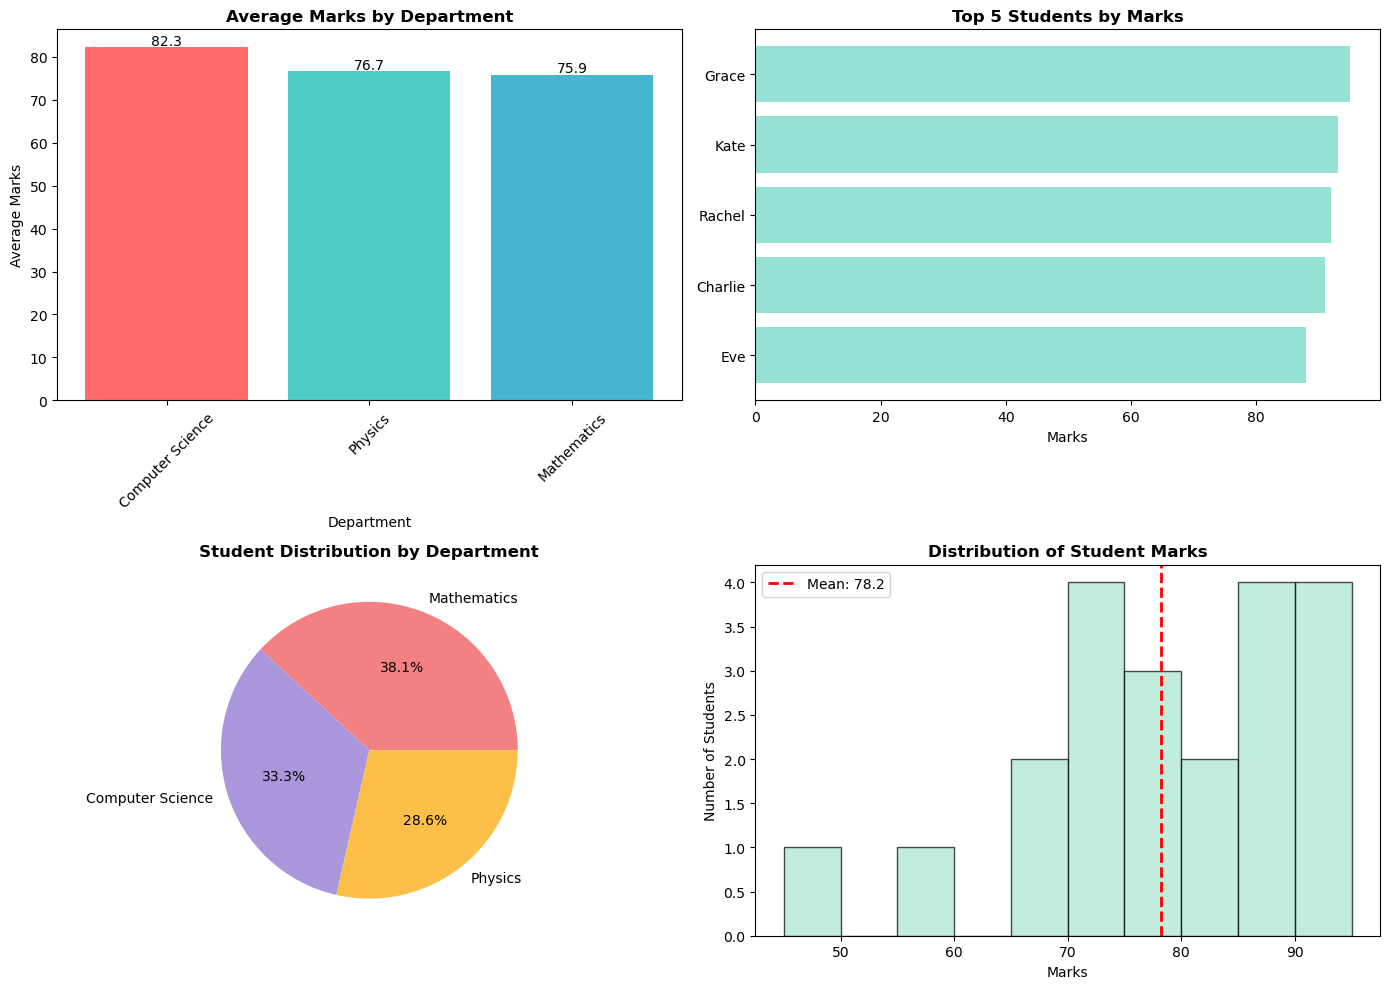


=== PERFORMANCE SUMMARY ===
Total Students (after cleaning): 21
Overall Average Marks: 78.24
Highest Marks: 95
Lowest Marks: 45

Top Department (by average): Computer Science with 82.29 average marks


In [14]:
# Convert to Pandas DataFrame for visualization
pandas_df = df_clean.toPandas()
avg_dept_df = avg_marks_per_dept_rounded.toPandas()

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average Marks by Department (Bar Chart)
axes[0, 0].bar(avg_dept_df['Department'], avg_dept_df['Average_Marks'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('Average Marks by Department', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Department')
axes[0, 0].set_ylabel('Average Marks')
axes[0, 0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(avg_dept_df['Average_Marks']):
    axes[0, 0].text(i, v + 0.5, str(round(v, 1)), ha='center')

# Plot 2: Top 5 Students (Horizontal Bar Chart)
top_5_pandas = top_5_students.toPandas()
axes[0, 1].barh(top_5_pandas['Name'], top_5_pandas['Marks'], color='#95E1D3')
axes[0, 1].set_title('Top 5 Students by Marks', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Marks')
axes[0, 1].invert_yaxis()

# Plot 3: Student Distribution by Department (Pie Chart)
dept_counts = pandas_df['Department'].value_counts()
axes[1, 0].pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%',
               colors=['#F38181', '#AA96DA', '#FCBF49'])
axes[1, 0].set_title('Student Distribution by Department', fontsize=12, fontweight='bold')

# Plot 4: Marks Distribution (Histogram)
axes[1, 1].hist(pandas_df['Marks'], bins=10, edgecolor='black', color='#A8E6CF', alpha=0.7)
axes[1, 1].set_title('Distribution of Student Marks', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Marks')
axes[1, 1].set_ylabel('Number of Students')
axes[1, 1].axvline(pandas_df['Marks'].mean(), color='red', linestyle='dashed', 
                   linewidth=2, label=f"Mean: {pandas_df['Marks'].mean():.1f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== PERFORMANCE SUMMARY ===")
print(f"Total Students (after cleaning): {df_clean.count()}")
print(f"Overall Average Marks: {pandas_df['Marks'].mean():.2f}")
print(f"Highest Marks: {pandas_df['Marks'].max()}")
print(f"Lowest Marks: {pandas_df['Marks'].min()}")
print(f"\nTop Department (by average): {avg_dept_df.iloc[0]['Department']} "
      f"with {avg_dept_df.iloc[0]['Average_Marks']:.2f} average marks")

In [17]:
# This cell is optional - skip if you get Hadoop errors
# df_clean.write.mode("overwrite").csv("cleaned_students.csv", header=True)
# avg_marks_per_dept_rounded.write.mode("overwrite").csv("avg_marks_by_dept.csv", header=True)
# top_5_students.write.mode("overwrite").csv("top_5_students.csv", header=True)
# print("Results exported successfully!")

print("Skipping file export - results are visible in notebook above.")
print("Taking screenshots of outputs is sufficient for submission.")

Skipping file export - results are visible in notebook above.
Taking screenshots of outputs is sufficient for submission.


In [18]:
# Stop the Spark session when done
spark.stop()
print("Spark Session Stopped.")

Spark Session Stopped.
